In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', None)

df = pd.read_csv('amazon_delivery.csv')
print("Shape:", df.shape)
df.head()

Shape: (7676, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120.0,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165.0,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130.0,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105.0,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150.0,Toys


In [2]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

for col in ['Weather', 'Traffic', 'Vehicle', 'Area']:
    print(f"\n{col} unique values:\n", df[col].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7676 entries, 0 to 7675
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         7676 non-null   object 
 1   Agent_Age        7676 non-null   int64  
 2   Agent_Rating     7666 non-null   float64
 3   Store_Latitude   7676 non-null   float64
 4   Store_Longitude  7676 non-null   float64
 5   Drop_Latitude    7676 non-null   float64
 6   Drop_Longitude   7676 non-null   float64
 7   Order_Date       7676 non-null   object 
 8   Order_Time       7676 non-null   object 
 9   Pickup_Time      7676 non-null   object 
 10  Weather          7664 non-null   object 
 11  Traffic          7676 non-null   object 
 12  Vehicle          7676 non-null   object 
 13  Area             7676 non-null   object 
 14  Delivery_Time    7675 non-null   float64
 15  Category         7675 non-null   object 
dtypes: float64(6), int64(1), object(9)
memory usage: 959.6+ KB
N

In [3]:
# Strip whitespace from categorical columns
for col in ['Weather', 'Traffic', 'Vehicle', 'Area']:
    df[col] = df[col].str.strip()

# Convert the literal text "NaN" into a true missing value
df['Traffic'] = df['Traffic'].replace('NaN', np.nan)

print("Traffic nulls after fix:", df['Traffic'].isnull().sum())

Traffic nulls after fix: 12


In [4]:
print("Missing before:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Agent_Rating: numeric, slightly skewed -> median imputation
df['Agent_Rating'] = df['Agent_Rating'].fillna(df['Agent_Rating'].median())

# Weather and Traffic: categorical with a small number of missing rows -> drop them
df = df.dropna(subset=['Weather', 'Traffic'])

print("\nMissing after:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Shape after handling missing values:", df.shape)

Missing before:
 Agent_Rating     10
Weather          12
Traffic          12
Delivery_Time     1
Category          1
dtype: int64

Missing after:
 Delivery_Time    1
Category         1
dtype: int64
Shape after handling missing values: (7664, 16)


In [5]:
before = len(df)

# Invalid GPS coordinates (store coords <= 0, drop coords near 0.01)
df = df[(df.Store_Latitude > 0) & (df.Store_Longitude > 0) &
        (df.Drop_Latitude > 1) & (df.Drop_Longitude > 1)]

# Implausible agent age and rating
df = df[(df.Agent_Age >= 18) & (df.Agent_Age <= 65)]
df = df[(df.Agent_Rating >= 1) & (df.Agent_Rating <= 5)]

print(f"Removed {before - len(df)} rows with invalid coordinates/age/rating")
print("Shape now:", df.shape)

Removed 655 rows with invalid coordinates/age/rating
Shape now: (7009, 16)


In [6]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin((p2 - p1) / 2) ** 2 +
         np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

df['dist_km'] = haversine(df.Store_Latitude, df.Store_Longitude,
                           df.Drop_Latitude, df.Drop_Longitude)

# Pickup wait time in minutes
order_dt  = pd.to_datetime(df.Order_Date + ' ' + df.Order_Time)
pickup_dt = pd.to_datetime(df.Order_Date + ' ' + df.Pickup_Time)
df['pickup_wait'] = (pickup_dt - order_dt).dt.total_seconds() / 60

# Remove logically impossible pickup times (pickup before order)
df = df[df['pickup_wait'] >= 0]

print(df[['dist_km', 'pickup_wait']].describe())

           dist_km  pickup_wait
count  6879.000000  6879.000000
mean      9.680533     9.845908
std       5.592464     4.093212
min       1.465067     5.000000
25%       4.657620     5.000000
50%       9.179538    10.000000
75%      13.622101    15.000000
max      20.969489    15.000000


Delivery_Time: bounds=(-15.0, 265.0), outliers found=12
dist_km: bounds=(-8.8, 27.1), outliers found=0
pickup_wait: bounds=(-10.0, 30.0), outliers found=0


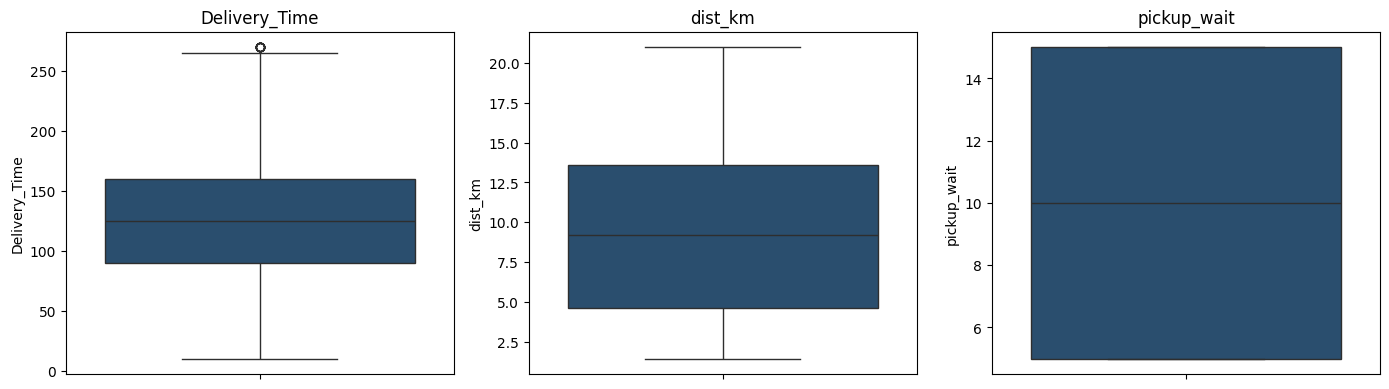

In [7]:
def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper, series[(series < lower) | (series > upper)]

for col in ['Delivery_Time', 'dist_km', 'pickup_wait']:
    lower, upper, outliers = detect_outliers_iqr(df[col])
    print(f"{col}: bounds=({lower:.1f}, {upper:.1f}), outliers found={len(outliers)}")

# Visualize with boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Delivery_Time', 'dist_km', 'pickup_wait']):
    sns.boxplot(y=df[col], ax=ax, color='#1F4E79')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [8]:
# Cap distance at 50 km (reasonable for last-mile; beyond this is likely bad GPS data)
before = len(df)
df = df[df['dist_km'] < 50]
print(f"Removed {before - len(df)} rows with dist_km >= 50 km")

# Cap pickup_wait at 30 minutes (longer waits are likely logging errors)
before = len(df)
df = df[df['pickup_wait'] <= 30]
print(f"Removed {before - len(df)} rows with pickup_wait > 30 min")

print("\nFinal shape after full cleaning:", df.shape)

Removed 0 rows with dist_km >= 50 km
Removed 0 rows with pickup_wait > 30 min

Final shape after full cleaning: (6879, 18)


In [9]:
# Min-Max scaling -> bounds values to [0,1], good for distance-based models (KNN, K-Means)
mm_scaler = MinMaxScaler()
df[['dist_km_minmax', 'Delivery_Time_minmax']] = mm_scaler.fit_transform(
    df[['dist_km', 'Delivery_Time']]
)

# Standardization -> mean=0, std=1, good for linear models and PCA
std_scaler = StandardScaler()
df[['Agent_Age_z', 'Agent_Rating_z']] = std_scaler.fit_transform(
    df[['Agent_Age', 'Agent_Rating']]
)

df[['dist_km', 'dist_km_minmax', 'Delivery_Time', 'Delivery_Time_minmax',
    'Agent_Age', 'Agent_Age_z']].head()

,dist_km,dist_km_minmax,Delivery_Time,Delivery_Time_minmax,Agent_Age,Agent_Age_z
0,3.025149,0.079986,120.0,0.423077,37,1.283354
1,20.183530,0.959704,165.0,0.596154,34,0.766158
2,1.552758,0.004496,130.0,0.461538,23,-1.130227
3,7.790401,0.324303,105.0,0.365385,38,1.455752
4,6.210138,0.243282,150.0,0.538462,32,0.421360


In [10]:
cat_cols = ['Weather', 'Traffic', 'Vehicle', 'Area']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after one-hot encoding:", df_encoded.shape)
df_encoded.head()

Shape after one-hot encoding: (6879, 32)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Delivery_Time,Category,dist_km,pickup_wait,dist_km_minmax,Delivery_Time_minmax,Agent_Age_z,Agent_Rating_z,Weather_Fog,Weather_Sandstorms,Weather_Stormy,Weather_Sunny,Weather_Windy,Traffic_Jam,Traffic_Low,Traffic_Medium,Vehicle_scooter,Vehicle_van,Area_Metropolitian,Area_Other,Area_Semi-Urban,Area_Urban
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,120.0,Clothing,3.025149,15.0,0.079986,0.423077,1.283354,0.862483,False,False,False,True,False,False,False,False,False,False,False,False,False,True
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,165.0,Electronics,20.183530,5.0,0.959704,0.596154,0.766158,-0.413779,False,False,True,False,False,True,False,False,True,False,True,False,False,False
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,130.0,Sports,1.552758,15.0,0.004496,0.461538,-1.130227,-0.732844,False,True,False,False,False,False,True,False,False,False,False,False,False,True
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,105.0,Cosmetics,7.790401,10.0,0.324303,0.365385,1.455752,0.224352,False,False,False,True,False,False,False,True,False,False,True,False,False,False
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,150.0,Toys,6.210138,15.0,0.243282,0.538462,0.421360,-0.094713,False,False,False,False,False,False,False,False,True,False,True,False,False,False


In [11]:
summary = pd.DataFrame({
    'Metric': ['Total rows', 'Missing values', 'Duplicate rows', 'Invalid coordinates',
               'Invalid age/rating', 'Outlier distance (>50km)', 'Outlier pickup wait (>30min)'],
    'Before cleaning': [43739, 145, 0, 3693, 91, 'N/A', 'N/A'],
    'After cleaning': [len(df), df.isnull().sum().sum(), df.duplicated().sum(),
                       0, 0, 0, 0]
})
print(summary)

# Save cleaned dataset for next week's analysis
df.to_csv('amazon_delivery_cleaned.csv', index=False)
print("\nCleaned dataset saved as amazon_delivery_cleaned.csv")

                         Metric Before cleaning  After cleaning
0                    Total rows           43739            6879
1                Missing values             145               3
2                Duplicate rows               0               0
3           Invalid coordinates            3693               0
4            Invalid age/rating              91               0
5      Outlier distance (>50km)             N/A               0
6  Outlier pickup wait (>30min)             N/A               0

Cleaned dataset saved as amazon_delivery_cleaned.csv


In [12]:
from google.colab import files
files.download('amazon_delivery_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>